# Customer Segmentation Using RFM Analysis and KMeans Clustering

## Project Overview

This project focuses on customer segmentation using behavioral data. The objective is to identify distinct customer groups based on their purchasing patterns and translate those insights into actionable business strategies.

The analysis follows a structured workflow:

1. Data Cleaning & Preparation  
2. Exploratory Data Analysis (EDA)  
3. RFM Feature Engineering  
4. Rule-Based Customer Segmentation  
5. Unsupervised Clustering (KMeans)  
6. Cluster Interpretation & Business Strategy  

By combining traditional RFM modeling with machine learning, this project aims to build a robust, data-driven customer segmentation framework.

## Dataset Overview

The dataset used in this project is the Online Retail dataset, which contains transactional data from a UK-based online retail store between 2010 and 2011.
Each row represents a single product line within an invoice.

Key columns include:
- `InvoiceNo`: Unique identifier for each invoice (cancellations start with 'C')
- `InvoiceDate`: Date and time of the transaction
- `CustomerID`: Unique identifier for each customer
- `Quantity`: Number of items purchased
- `UnitPrice`: Price per item

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

## Visualization Settings

This section defines consistent visualization styles to be applied across all plots in the notebook for better readability and presentation.

In [ ]:
# -----------------------------
# 1. Global Style Configuration
# -----------------------------
sns.set_theme(
    style= "whitegrid",
    context= "notebook",
    font= "Times New Roman",
    font_scale= 1.1
)

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# -----------------------------
# 2. Advanced Smart Annotation
# -----------------------------
def annotate_smart(ax_or_g, min_height_ratio= 0.07):
    """
    Advanced smart annotation for bar-based plots.
    - Handles small bars automatically
    - Works with FacetGrid or single axis
    - Supports counts and percentages
    - Adjusts text contrast dynamically
    """

    if isinstance(ax_or_g, sns.axisgrid.FacetGrid):
        axes = ax_or_g.axes.flat
    else:
        axes = [ax_or_g]

    for ax in axes:
        ymax = ax.get_ylim()[1]

        for container in ax.containers:
            for patch in container:
                height = patch.get_height()
                if height <= 0:
                    continue

                x = patch.get_x() + patch.get_width() / 2

                # Determine placement
                if height < ymax * min_height_ratio:
                    y = height + ymax * 0.02
                    va = "bottom"
                    inside = False
                else:
                    y = height / 2
                    va = "center"
                    inside = True

                # Dynamic text formatting
                if height < 10:
                    label = f"{height:.1f}"
                else:
                    label = f"{int(height)}"

                # Dynamic contrast
                facecolor = patch.get_facecolor()
                brightness = (0.299 * facecolor[0] + 
                              0.587 * facecolor[1] + 
                              0.114 * facecolor[2])

                if inside:
                    color = "white" if brightness < 0.5 else "black"
                else:
                    color = "black"

                ax.text(
                    x, y, label,
                    ha= "center",
                    va= va,
                    fontsize= 9,
                    fontweight= "bold",
                    color= "black"
                )

        ax.grid(False)


# -----------------------------
# 3. Barplot Template 
# -----------------------------
def plot_barplot(data, x, y, hue= None,
                 palette= None, order= None,
                 title="", xlabel= None, ylabel= None):

    ax = sns.barplot(
        data= data,
        x= x,
        y= y,
        hue= hue,
        palette= palette,
        order= order
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)

    if hue:
        ax.legend(title= hue)

    annotate_smart(ax)

    plt.tight_layout()
    plt.show()

    return ax


# -----------------------------
# 4. Boxplot Template
# -----------------------------
def plot_boxplot(data, x= None, y= None,
                 hue= None, palette= None,
                 title= "", xlabel= None, ylabel= None):

    ax = sns.boxplot(data= data, x= x, y= y,
                     hue= hue, palette= palette)

    ax.set_title(title)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)

    if hue:
        ax.legend(title= hue)

    plt.tight_layout()
    plt.show()

    return ax


# -----------------------------
# 5. Histplot Template
# -----------------------------
def plot_histplot(data, x, hue= None,
                  palette= None, bins= 30,
                  multiple= "stack",
                  title= "", xlabel= None,
                  ylabel= "Count"):

    ax = sns.histplot(
        data= data,
        x= x,
        hue= hue,
        palette= palette,
        bins= bins,
        multiple= multiple
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel)

    ax.grid(False)

    plt.tight_layout()
    plt.show()

    return ax


## Data Loading

In this section, the dataset is loaded and basic inspections are performed
to understand its structure and contents.

In [3]:
df = pd.read_csv("Online Retail.csv", encoding= "latin1")

### Exploratory Data Analysis (EDA) EDA

The purpose of this exploratory analysis is to identify data quality issues and understand the overall structure of the dataset in order to support
informed data cleaning and preparation for RFM analysis.

In [4]:
df.shape

(541909, 8)

In [5]:
len(df)

541909

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
df.describe(include= "object")

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [12]:
print(f"InvoiceDate_min: {df["InvoiceDate"].min()}")
print(f"InvoiceDate_max: {df["InvoiceDate"].max()}")

InvoiceDate_min: 1/10/2011 10:04
InvoiceDate_max: 9/9/2011 9:52


In [13]:
df.mean

<bound method DataFrame.mean of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custome

In [14]:
df.std

<bound method DataFrame.std of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Customer

In [15]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [16]:
print((df.isnull().sum() / len(df) * 100).round(2))

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


Text(0.5, 1.0, 'Customer Segmentation Missing Value')

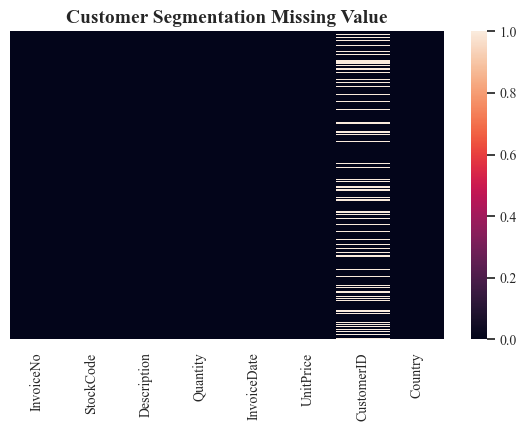

In [17]:
ax = sns.heatmap(df.isnull(), 
                 yticklabels= False, 
                 cbar= True)

ax.set_title("Customer Segmentation Missing Value")

In [18]:
columns_of_data = df.columns

for col in columns_of_data:
    print(col, df[col].unique())

InvoiceNo ['536365' '536366' '536367' ... '581585' '581586' '581587']
StockCode ['85123A' '71053' '84406B' ... '90214U' '47591b' '23843']
Description ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' ... 'lost'
 'CREAM HANGING HEART T-LIGHT HOLDER' 'PAPER CRAFT , LITTLE BIRDIE']
Quantity [     6      8      2     32      3      4     24     12     48     18
     20     36     80     64     10    120     96     23      5      1
     -1     50     40    100    192    432    144    288    -12    -24
     16      9    128     25     30     28      7     56     72    200
    600    480     -6     14     -2     11     33     13     -4     -5
     -7     -3     70    252     60    216    384    -10     27     15
     22     19     17     21     34     47    108     52  -9360    -38
     75    270     42    240     90    320   1824    204     69    -36
   -192   -144    160   2880   1400     39    -48    -50     26   1440
     31     82     78     97

## Data Type Correction

Before performing any analysis or visualization, data types are corrected to
ensure accurate interpretation of the dataset, particularly for time-based
and identifier columns.

In [19]:
copy_data = df.copy()

In [20]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format= "%m/%d/%Y %H:%M")

In [21]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

In [22]:
df["CustomerID"] = df["CustomerID"].fillna("Unknown").astype(str)

In [23]:
df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [24]:
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [25]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [26]:
df["Revenue"].describe()

count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64

In [27]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [28]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country',
 'Revenue',
 'Year',
 'Month',
 'Day',
 'Hour',
 'DayOfWeek',
 'YearMonth']

In [29]:
print("Country Distribution:")
country_counts = df["Country"].value_counts()
print(f"Number of Different Countries: {len(country_counts)}")
print(f"\nTop 10 Countries: {country_counts.head(10)}")

Country Distribution:
Number of Different Countries: 38

Top 10 Countries: Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


In [30]:
country_customers = (
    df.dropna(subset= ["CustomerID"])
    .groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending= False)
    .reset_index()
)


country_customers.columns = ["Country", "Num_Customers"]

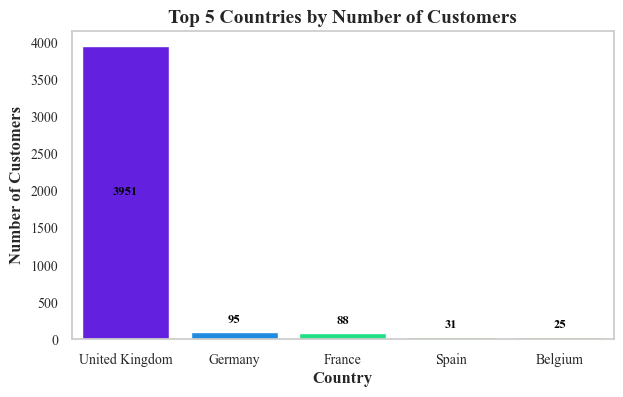

In [31]:
ax = sns.barplot(
    data= country_customers.head(5),
    x= "Country",
    y= "Num_Customers",
    palette= "gist_rainbow_r"
)

ax.set_title("Top 5 Countries by Number of Customers")
ax.set_xlabel("Country")
ax.set_ylabel("Number of Customers")

annotate_smart(ax)
plt.show()

In [32]:
country_records = (
    df["Country"].value_counts().reset_index()
)

country_records.columns = ["Country", "Num_Records"]

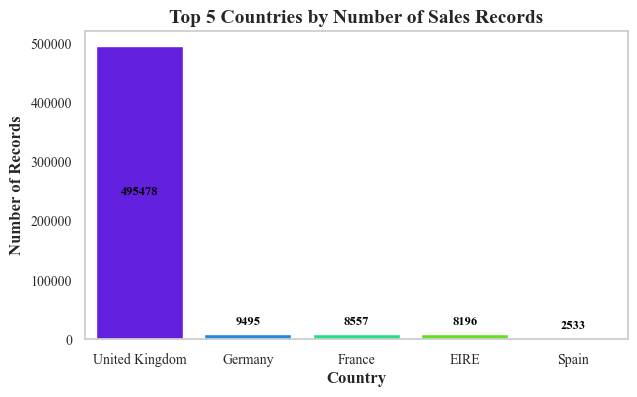

In [33]:
ax = sns.barplot(
    data= country_records.head(5),
    x= "Country",
    y= "Num_Records",
    palette= "gist_rainbow_r"
)

ax.set_title("Top 5 Countries by Number of Sales Records")
ax.set_xlabel("Country")
ax.set_ylabel("Number of Records")

annotate_smart(ax)
plt.show()

In [34]:
country_invoices = (
    df.dropna(subset= ["CustomerID"])
    .groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending= False)
    .reset_index()
)

country_invoices.columns = ["Country", "Num_Invoices"]

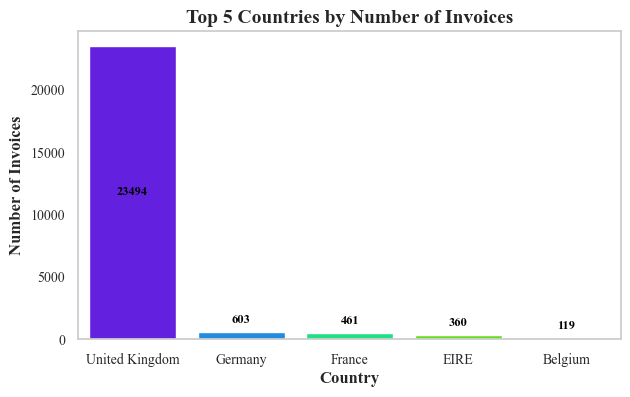

In [35]:
ax = sns.barplot(
    data= country_invoices.head(5),
    x= "Country",
    y= "Num_Invoices",
    palette= "gist_rainbow_r"
)

ax.set_title("Top 5 Countries by Number of Invoices")
ax.set_xlabel("Country")
ax.set_ylabel("Number of Invoices")

annotate_smart(ax)
plt.show()

In [36]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending= False)
      .reset_index()
)

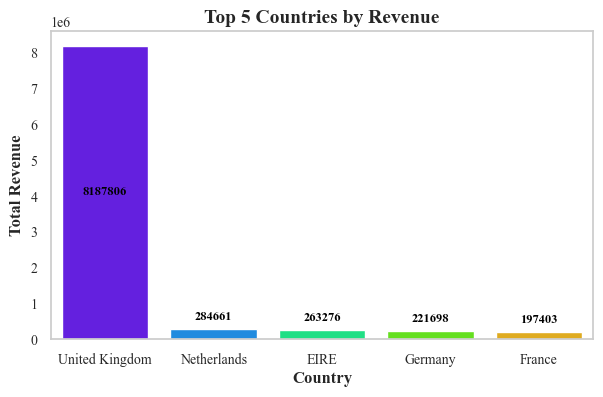

In [37]:
ax = sns.barplot(
    data= country_revenue.head(5),
    x= "Country",
    y= "Revenue",
    palette= "gist_rainbow_r"
)

ax.set_title("Top 5 Countries by Revenue")
ax.set_xlabel("Country")
ax.set_ylabel("Total Revenue")

annotate_smart(ax)
plt.show()

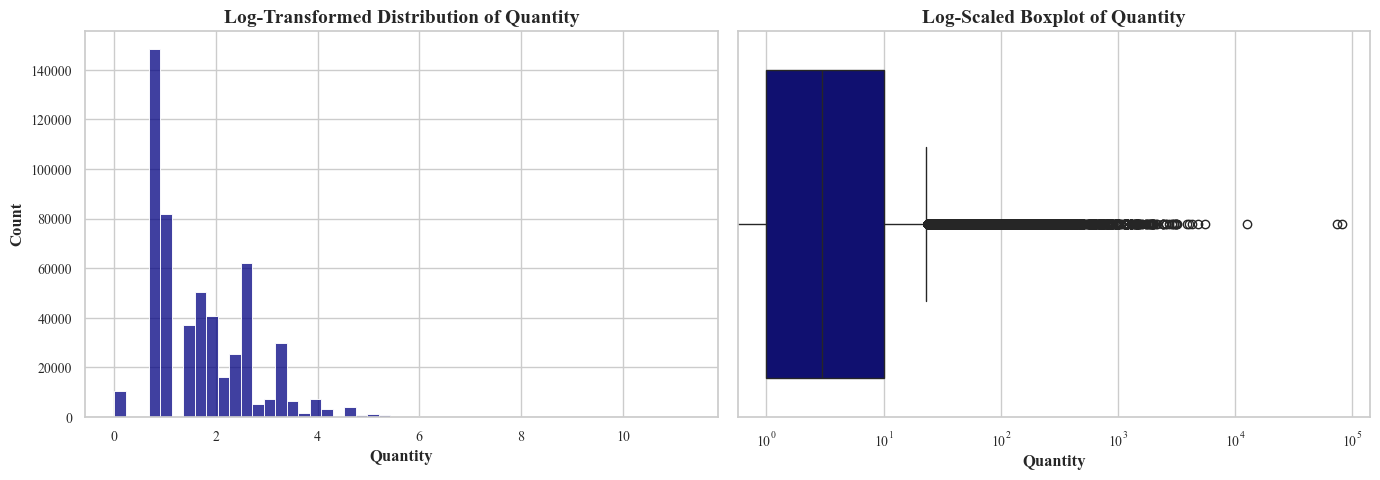

In [38]:
fig, axes = plt.subplots(1, 2, figsize= (14, 5))

sns.histplot(
    np.log1p(df["Quantity"].clip(lower= 0)),
    bins= 50,
    kde= False,
    color= "navy",
    ax=axes[0]
)
axes[0].set_title("Log-Transformed Distribution of Quantity")

sns.boxplot(
    x= df["Quantity"],
    ax= axes[1],
    color= "navy"
)
axes[1].set_xscale("log")
axes[1].set_title("Log-Scaled Boxplot of Quantity")

plt.tight_layout()
plt.show()

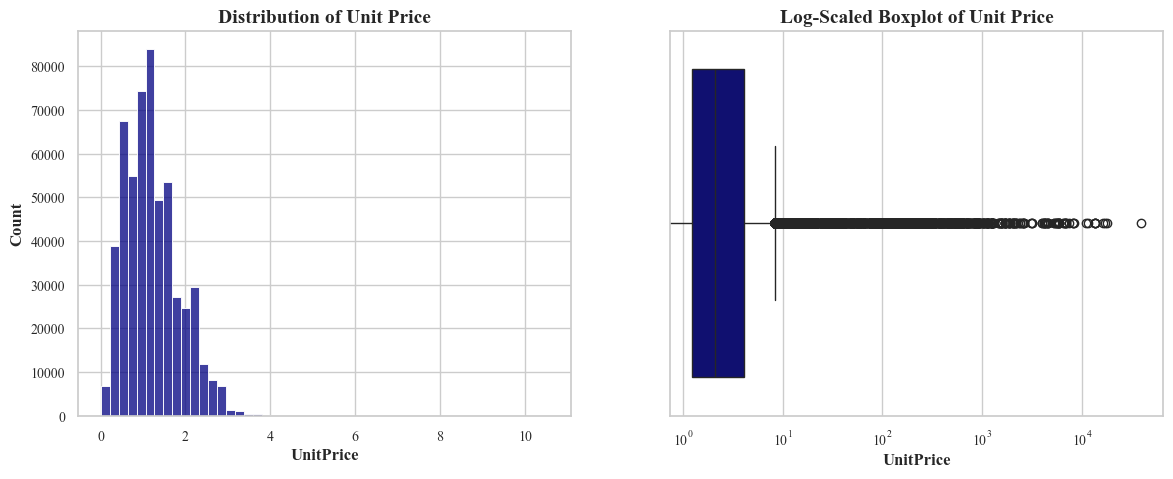

In [39]:
fig, axes = plt.subplots(1, 2, figsize= (14, 5))

sns.histplot(
    np.log1p(df["UnitPrice"]),
    bins= 50,
    kde= False,
    color= "navy",
    ax= axes[0]
)
axes[0].set_title("Distribution of Unit Price")
axes[0].set_xlabel("UnitPrice")
axes[0].set_ylabel("Count")

sns.boxplot(
    x= df["UnitPrice"],
    ax= axes[1],
    color= "navy"
)
axes[1].set_xscale("log")
axes[1].set_title("Log-Scaled Boxplot of Unit Price")

plt.show()

In [40]:
monthly_revenue = (
    df.set_index("InvoiceDate")
    .resample("M")["Revenue"]
    .sum()
)

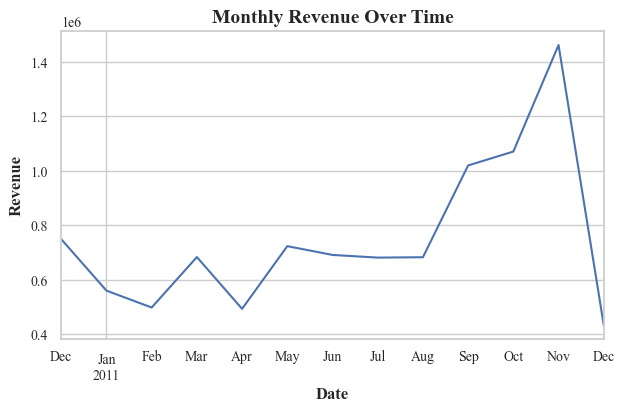

In [41]:
monthly_revenue.plot()
plt.title("Monthly Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [42]:
monthly_invoices = (
    df.set_index("InvoiceDate")
      .resample("M")["InvoiceNo"]
      .nunique()
)

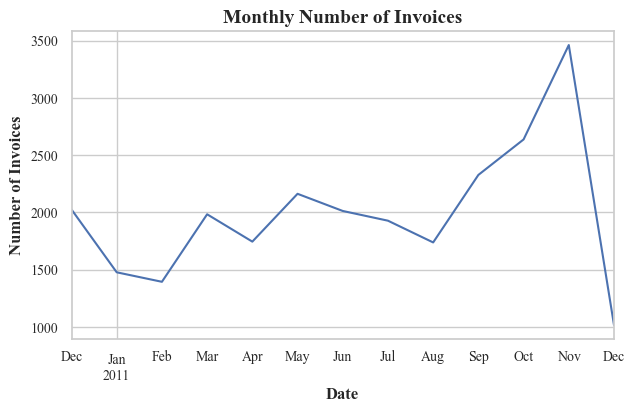

In [43]:
monthly_invoices.plot()
plt.title("Monthly Number of Invoices")
plt.xlabel("Date")
plt.ylabel("Number of Invoices")
plt.show()

In [44]:
snapshot_date= df["InvoiceDate"].max() + pd.Timedelta(days= 1)

recency = (
    df.dropna(subset= ["CustomerID"])
    .groupby("CustomerID")["InvoiceDate"]
    .max()
)

recency_days = (snapshot_date - recency).dt.days

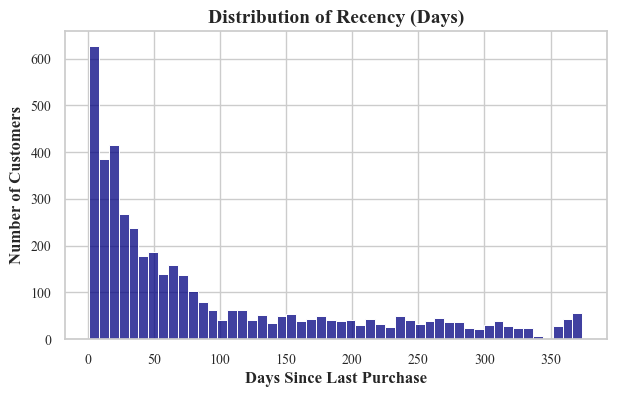

In [45]:
sns.histplot(recency_days, bins= 50, kde= False, color= "navy")
plt.title("Distribution of Recency (Days)")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.show()

This section performs a minimal exploratory analysis to support data cleaning
and feature engineering decisions for RFM analysis.

In [46]:
print(f"Shape of Data Frame: {df.shape}")
print(f"CustomerID_nunique: {df["CustomerID"].nunique()}")
print(f"InvoiceNo_nunique: {df["InvoiceNo"].nunique()}")

Shape of Data Frame: (541909, 15)
CustomerID_nunique: 4373
InvoiceNo_nunique: 25900


In [47]:
print(f"InvoiceDate_min: {df["InvoiceDate"].min()}")
print(f"InvoiceDate_max: {df["InvoiceDate"].max()}")

InvoiceDate_min: 2010-12-01 08:26:00
InvoiceDate_max: 2011-12-09 12:50:00


In [48]:
{
    "missing_customer_id": df["CustomerID"].isna().sum(),
    "quantity_non_positive": (df["Quantity"] <= 0).sum(),
    "unitprice_non_positive": (df["UnitPrice"] <= 0).sum(),
    "cancelled_invoices": df["InvoiceNo"].astype(str).str.startswith("C").sum()
}


{'missing_customer_id': 0,
 'quantity_non_positive': 10624,
 'unitprice_non_positive': 2517,
 'cancelled_invoices': 9288}

In [49]:
unknown_customers = df[df["CustomerID"] == "Unknown"]
print(f"Number of records with unknown CustomerID: {len(unknown_customers)}")

print("\nCountry distribution for anonymous customers:")
print(unknown_customers["Country"].value_counts().head())

Number of records with unknown CustomerID: 135080

Country distribution for anonymous customers:
Country
United Kingdom    133600
EIRE                 711
Hong Kong            288
Unspecified          202
Switzerland          125
Name: count, dtype: int64


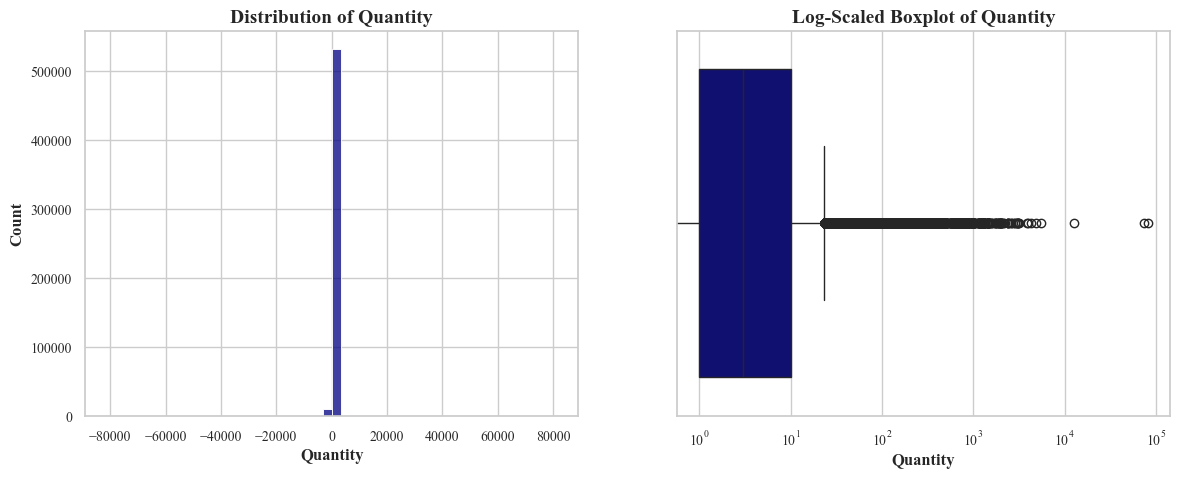

In [50]:
fig, axes = plt.subplots(1, 2, figsize= (14, 5))

sns.histplot(
    df["Quantity"],
    bins= 50,
    kde= False,
    color= "navy",
    ax= axes[0]
)
axes[0].set_title("Distribution of Quantity")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Count")

sns.boxplot(
    x= df["Quantity"],
    ax= axes[1],
    color= "navy"
)
axes[1].set_xscale("log")
axes[1].set_title("Log-Scaled Boxplot of Quantity")

plt.show()

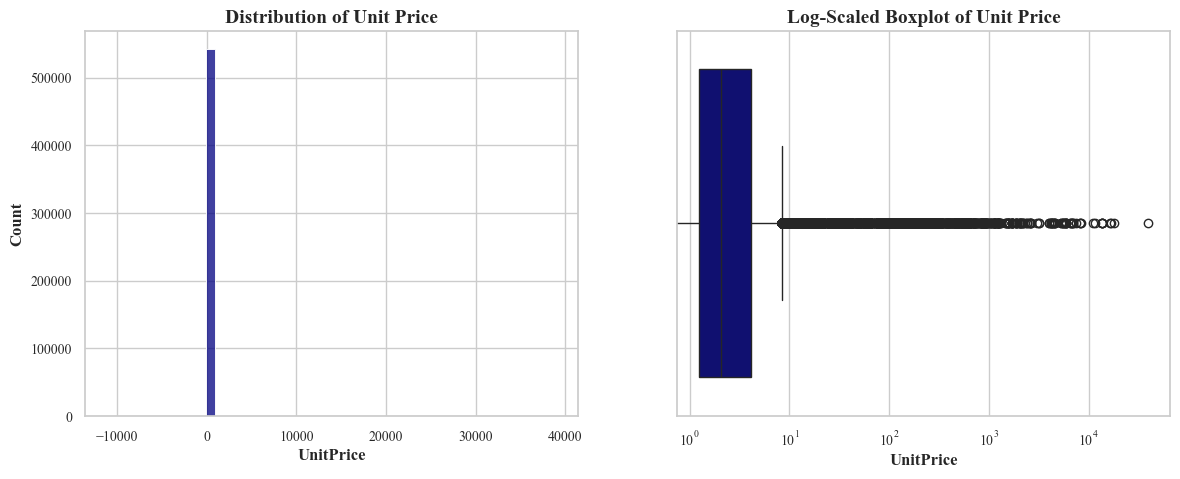

In [51]:
fig, axes = plt.subplots(1, 2, figsize= (14, 5))

sns.histplot(
    df["UnitPrice"],
    bins= 50,
    kde= False,
    color= "navy",
    ax= axes[0]
)
axes[0].set_title("Distribution of Unit Price")
axes[0].set_xlabel("UnitPrice")
axes[0].set_ylabel("Count")

sns.boxplot(
    x= df["UnitPrice"],
    ax= axes[1],
    color= "navy"
)
axes[1].set_xscale("log")
axes[1].set_title("Log-Scaled Boxplot of Unit Price")

plt.show()

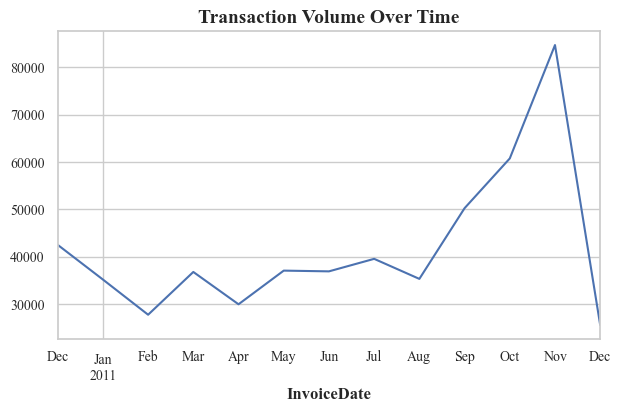

In [52]:
df.set_index("InvoiceDate").resample("M").size().plot()
plt.title("Transaction Volume Over Time")
plt.show()

### EDA Summary

Based on the exploratory analysis above, several data quality issues were identified, including missing customer identifiers, cancelled invoices, and transactions with non-positive quantities or prices. These observations will guide the data cleaning steps in the following section.

## Data Cleaning

Based on the findings from the exploratory data analysis, this section applies data cleaning steps to remove invalid or irrelevant transactions and prepare
the dataset for RFM feature engineering.

In [53]:
df.drop("Description", axis= 1, inplace= True)

In [54]:
# Analyze anonymous customers before deletion

unknown_customers = df[df["CustomerID"] == "Unknown"]

print("Anonymous Customer Analysis:")
print(f"Number: {len(unknown_customers)}")
print(f"Percentage of total: {(len(unknown_customers)/len(df)*100):.2f}%")
print(f"Number of unique factors: {unknown_customers["InvoiceNo"].nunique()}")
print(f"Total sales: {unknown_customers["Revenue"].sum():.2f}")
print("\nDistribution of countries:")
print(unknown_customers["Country"].value_counts().head(10))

# Check Have these customers made any major purchases?
print(f"\nMost purchased by an anonymous customer: {unknown_customers["Revenue"].max():.2f}")
print(f"Average purchase of anonymous customers: {unknown_customers["Revenue"].mean():.2f}")

Anonymous Customer Analysis:
Number: 135080
Percentage of total: 24.93%
Number of unique factors: 3710
Total sales: 1447682.12

Distribution of countries:
Country
United Kingdom    133600
EIRE                 711
Hong Kong            288
Unspecified          202
Switzerland          125
France                66
Israel                47
Portugal              39
Bahrain                2
Name: count, dtype: int64

Most purchased by an anonymous customer: 13541.33
Average purchase of anonymous customers: 10.72


In [55]:
df_without_unknown = df[df["CustomerID"] != "Unknown"].copy()

df = df[df["CustomerID"] != "Unknown"]

Transactions without a valid CustomerID were excluded from the analysis, as RFM segmentation requires customer-level identification. Although these transactions represent a significant portion of the dataset, they cannot be meaningfully used for behavioral segmentation.

In [56]:
print(f"Count: {(df["Quantity"] < 0).sum()}")
print(f"Percentage: {((df["Quantity"] < 0).sum() / len(df) * 100).round(2)}%")

Count: 8905
Percentage: 2.19%


In [57]:
print(f"Count: {(df["UnitPrice"] <= 0).sum()}")
print(f"Percentage: {((df["UnitPrice"] <= 0).sum() / len(df) * 100).round(2)}%")

Count: 40
Percentage: 0.01%


In [58]:
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C")
print(f"Number of Canceled Invoices: {df["IsCancelled"].sum()}")
print(f"Percentage of Canceled Invoices: {(df["IsCancelled"].sum() / len(df) * 100).round(2)}%")

Number of Canceled Invoices: 8905
Percentage of Canceled Invoices: 2.19%


In [59]:
df = df[~df["InvoiceNo"].str.startswith("C")]

In [60]:
unique_stock_codes = df["StockCode"].unique()
non_standard_codes  = [code for code in unique_stock_codes if not (str(code).replace(" ", "").isalnum() and len(str(code)) <= 10)]
print(f"Number of unusual codes: {len(non_standard_codes)}")
print(f"Example of unusual codes: {non_standard_codes[:10]}")

Number of unusual codes: 1
Example of unusual codes: ['BANK CHARGES']


## RFM Feature Engineering

In this section, transactional data is transformed into customer-level features using the RFM (Recency, Frequency, Monetary) framework. The goal is to summarize each customer's purchasing behavior in a way that enables effective segmentation and clustering.

In [61]:
# Reference date for Recency calculation
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days= 1)
reference_date

Timestamp('2011-12-10 12:50:00')

### Reference Date Definition

To calculate Recency consistently across all customers, a reference date is defined as one day after the last transaction date in the dataset.

In [62]:
# Calculate Recency for each customer
recency_df = (
    df.groupby("CustomerID")["InvoiceDate"]
    .max()
    .reset_index()
)

recency_df["Recency"] = (reference_date - recency_df["InvoiceDate"]).dt.days
recency_df.head()

,CustomerID,InvoiceDate,Recency
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310


Recency measures how recently a customer made a purchase. Customers with lower recency values have interacted with the business more recently and are generally considered more engaged.

In [63]:
recency_df["Recency"].describe()

count    4339.000000
mean       92.518322
std       100.009747
min         1.000000
25%        18.000000
50%        51.000000
75%       142.000000
max       374.000000
Name: Recency, dtype: float64

### Frequency Calculation

In [64]:
frequency_df = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns= {"InvoiceNo": "Frequency"})
)

frequency_df.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [65]:
frequency_df.describe()

,Frequency
count,4339.000000
mean,4.271952
std,7.705493
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,210.000000


Frequency represents how often a customer makes purchases. It is calculated as the number of unique invoices associated with each customer, ensuring that multiple items within the same transaction are not overcounted.

### Monetary Calculation

In [66]:
df_monetary = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

In [67]:
# Calculate transaction value
df_monetary["TotalPrice"] = (
    df_monetary["Quantity"] * df_monetary["UnitPrice"]
)

# Aggregate monetary value per customer
monetary_df = (
    df_monetary.groupby("CustomerID")["TotalPrice"]
    .sum()
    .reset_index()
    .rename(columns= {"TotalPrice": "Monetary"})
)

monetary_df.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [68]:
monetary_df.describe()

,Monetary
count,4338.000000
mean,2054.266460
std,8989.230441
min,3.750000
25%,307.415000
50%,674.485000
75%,1661.740000
max,280206.020000


Monetary reflects the total revenue generated by each customer. It is calculated by summing the monetary value of all completed transactions, where transaction value is defined as Quantity multiplied by UnitPrice. Returned or cancelled transactions are excluded to ensure monetary values reflect actual spending behavior.

### RFM Table Construction

In [69]:
rfm = (
    recency_df
    .merge(frequency_df, on= "CustomerID", how= "inner")
    .merge(monetary_df, on= "CustomerID", how= "inner")
)

rfm.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary
0,12346.0,2011-01-18 10:01:00,326,1,77183.60
1,12347.0,2011-12-07 15:52:00,2,7,4310.00
2,12348.0,2011-09-25 13:13:00,75,4,1797.24
3,12349.0,2011-11-21 09:51:00,19,1,1757.55
4,12350.0,2011-02-02 16:01:00,310,1,334.40


In [70]:
rfm.shape

(4338, 5)

In [71]:
rfm.isna().sum()

CustomerID     0
InvoiceDate    0
Recency        0
Frequency      0
Monetary       0
dtype: int64

The RFM table aggregates Recency, Frequency, and Monetary values at the customer level. An inner join is applied to ensure that only customers with valid values for all three metrics are included in the segmentation analysis.

## Exploratory Data Analysis on RFM Features

Before applying scoring or clustering techniques, an exploratory analysis is performed on the RFM features to understand their distributions, scale differences, and potential skewness.

In [72]:
rfm.describe()

,InvoiceDate,Recency,Frequency,Monetary
count,4338,4338.000000,4338.000000,4338.000000
mean,2011-09-08 11:38:59.045643008,92.536422,4.272706,2054.266460
min,2010-12-01 09:53:00,1.000000,1.000000,3.750000
25%,2011-07-20 19:18:00,18.000000,1.000000,307.415000
50%,2011-10-20 10:40:30,51.000000,2.000000,674.485000
75%,2011-11-22 11:05:45,142.000000,5.000000,1661.740000
max,2011-12-09 12:50:00,374.000000,210.000000,280206.020000
std,NaN,100.014169,7.706221,8989.230441


Summary statistics confirm that all three RFM variables are positively skewed, with Monetary showing the highest degree of skewness due to the presence of
high-spending customers.

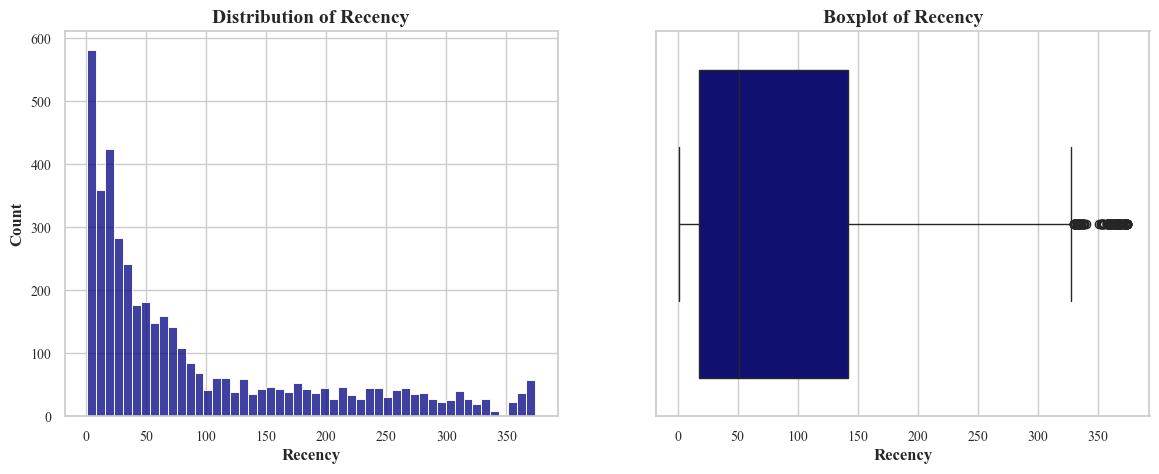

In [73]:
fig, axes = plt.subplots(1, 2, figsize= (14, 5))

sns.histplot(
    rfm["Recency"],
    bins= 50,
    kde= False,
    color= "navy",
    ax= axes[0]
)
axes[0].set_title("Distribution of Recency")
axes[0].set_xlabel("Recency")
axes[0].set_ylabel("Count")

sns.boxplot(
    x= rfm["Recency"],
    ax= axes[1],
    color= "navy"
)
axes[1].set_title("Boxplot of Recency")

plt.show()

The distribution of Recency indicates that while a portion of customers have purchased recently, a long tail of customers has not interacted with the business for an extended period.

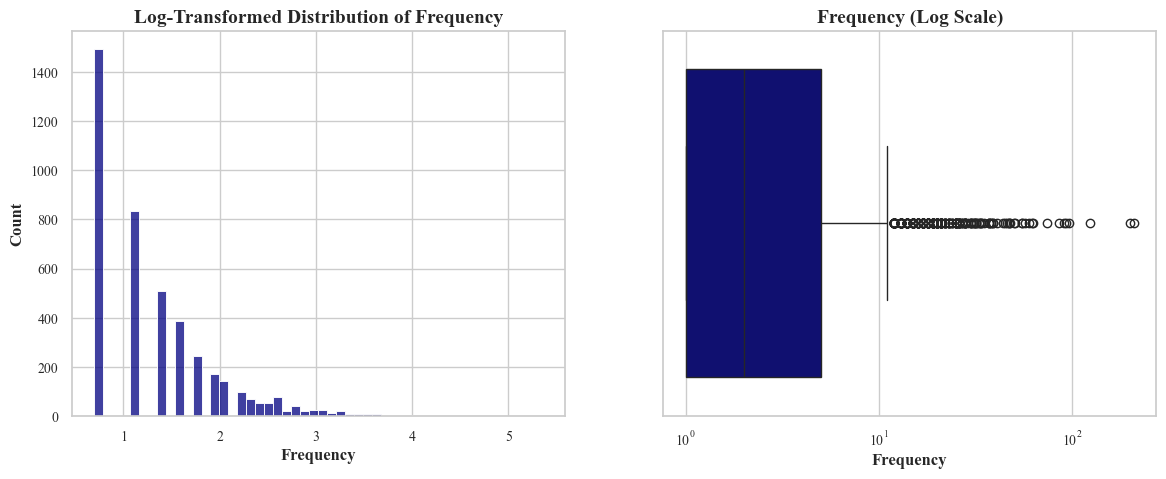

In [74]:
fig, axes = plt.subplots(1, 2, figsize= (14, 5))

sns.histplot(
    np.log1p(rfm["Frequency"]),
    bins= 50,
    kde= False,
    color= "navy",
    ax= axes[0]
)
axes[0].set_title("Log-Transformed Distribution of Frequency")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Count")

sns.boxplot(
    x= rfm["Frequency"],
    ax= axes[1],
    color= "navy"
)
axes[1].set_xscale("log")
axes[1].set_title("Frequency (Log Scale)")

plt.show()

Frequency is heavily right-skewed, showing that most customers make only a small number of purchases, while a limited group exhibits high repeat purchasing behavior.

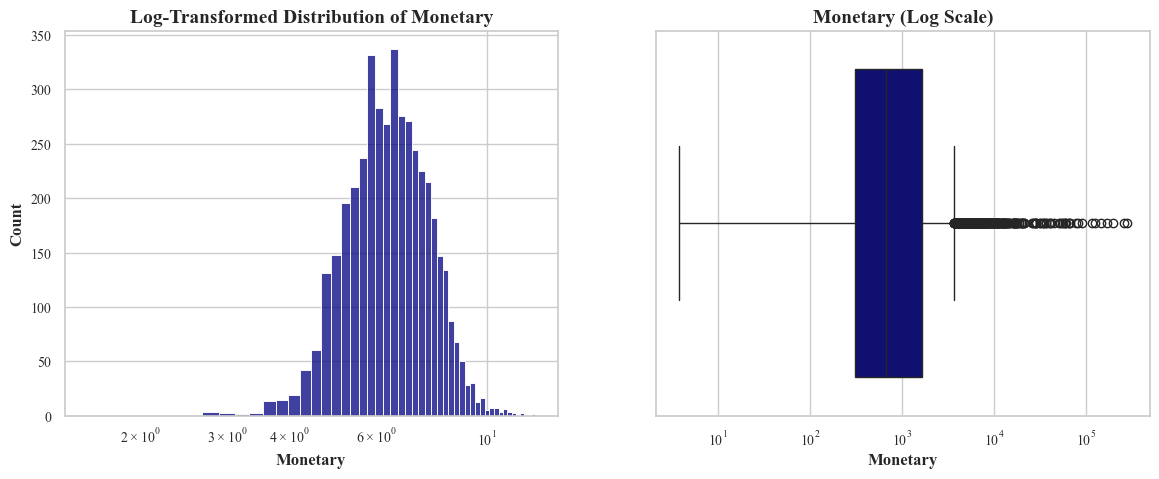

In [75]:
fig, axes = plt.subplots(1, 2, figsize= (14, 5))

sns.histplot(
    np.log1p(rfm["Monetary"]),
    bins= 50,
    kde= False,
    color= "navy",
    ax= axes[0]
)
axes[0].set_xscale("log")
axes[0].set_title("Log-Transformed Distribution of Monetary")
axes[0].set_xlabel("Monetary")
axes[0].set_ylabel("Count")

sns.boxplot(
    x= rfm["Monetary"],
    ax= axes[1],
    color= "navy"
)
axes[1].set_xscale("log")
axes[1].set_title("Monetary (Log Scale)")

plt.show()

Monetary values are highly skewed, with a small number of customers contributing a disproportionately large share of total revenue.

The observed skewness and scale differences across RFM variables highlight the need for appropriate transformation or scaling before applying clustering
algorithms.

## RFM Scoring

To enable customer segmentation, raw RFM values are converted into quantile-based scores ranging from 1 to 5. This approach ranks customers relative to one another instead of relying on absolute values.

A 5-quantile scoring system is used to balance segmentation granularity and interpretability.

In [76]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q= 5,
    labels= [5, 4, 3, 2, 1]
)

Recency scores are assigned in reverse order, as lower recency values indicate more recent customer activity.

In [77]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method= "first"),
    q= 5,
    labels= [1, 2, 3, 4, 5]
)

In [78]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q= 5,
    labels= [1, 2, 3, 4, 5]
)

Frequency and Monetary scores are assigned such that higher values receive higher scores, reflecting stronger engagement and higher spending behavior.

In [79]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

The combined RFM score provides a three-digit representation of customer behavior, enabling intuitive segmentation based on recency, frequency, and monetary value.

In [80]:
rfm.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,2011-01-18 10:01:00,326,1,77183.60,1,1,5,115
1,12347.0,2011-12-07 15:52:00,2,7,4310.00,5,5,5,555
2,12348.0,2011-09-25 13:13:00,75,4,1797.24,2,4,4,244
3,12349.0,2011-11-21 09:51:00,19,1,1757.55,4,1,4,414
4,12350.0,2011-02-02 16:01:00,310,1,334.40,1,1,2,112


In [81]:
rfm["RFM_Score"].value_counts().head()

RFM_Score
555    348
111    183
455    178
121    153
112    128
Name: count, dtype: int64

## Customer Segmentation Based on RFM Scores

Customers are segmented into meaningful behavioral groups based on their RFM score combinations. This rule-based approach translates numerical scores into actionable marketing segments.

In [82]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [83]:
def segment_customer(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Champions"
    
    elif row["R_Score"] >= 3 and row["F_Score"] >= 4:
        return "Loyal Customers"
    
    elif row["R_Score"] >= 4 and row["F_Score"] <= 2:
        return "Potential Loyalists"
    
    elif row["R_Score"] <= 2 and row["F_Score"] >= 4:
        return "At Risk"
    
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Lost"
    
    else:
        return "Others"

In [84]:
rfm["Segment"] = rfm.apply(segment_customer, axis= 1)

Segments are defined using business rules primarily based on Recency and Frequency scores. This approach provides interpretable groupings that can directly inform marketing strategies.

In [85]:
rfm["Segment"].value_counts()

Segment
Others                 1219
Champions              1139
Lost                   1065
Loyal Customers         321
Potential Loyalists     319
At Risk                 275
Name: count, dtype: int64

In [86]:
rfm["Segment"].value_counts(normalize= True) * 100

Segment
Others                 28.100507
Champions              26.256339
Lost                   24.550484
Loyal Customers         7.399723
Potential Loyalists     7.353619
At Risk                 6.339327
Name: proportion, dtype: float64

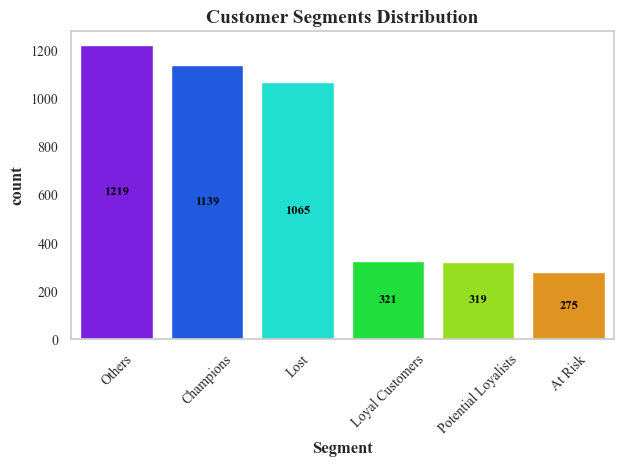

In [87]:
ax = sns.countplot(data= rfm, 
                   x= "Segment", 
                   order= rfm["Segment"].value_counts().index, 
                   palette= "gist_rainbow_r")

plt.xticks(rotation= 45)
ax.set_title("Customer Segments Distribution")

annotate_smart(ax)
plt.show()

The segmentation reveals distinct behavioral groups, with a relatively small proportion of high-value customers (Champions) and a larger share of low-engagement customers. This distribution is typical in retail datasets.

## Segment-Level Behavioral Analysis

To better understand customer segments, average RFM values are analyzed for each group. This helps validate whether the segmentation logic correctly reflects behavioral differences.

In [88]:
segment_summary = (
    rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .sort_values(by= "Monetary", ascending= False)
)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
Champions,13.311677,9.988586,5204.323012
Loyal Customers,50.582555,5.682243,2416.999875
At Risk,137.076364,4.894545,1575.407236
Others,77.407711,1.984413,909.774324
Lost,217.897653,1.101408,487.707579
Potential Loyalists,18.517241,1.241379,458.202414


The segment-level averages confirm the validity of the rule-based segmentation. Champions exhibit low recency and high frequency and monetary values, while Lost customers show high recency and low engagement metrics.

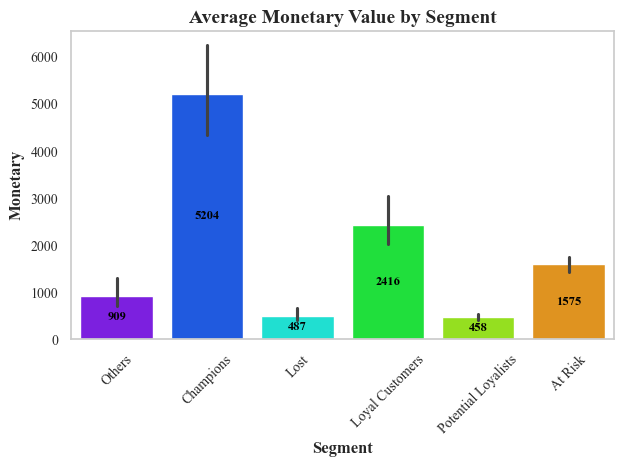

In [89]:
ax= sns.barplot(data= rfm, 
                x= "Segment", y= "Monetary",
                order= rfm["Segment"].value_counts().index,
                palette= "gist_rainbow_r")

plt.xticks(rotation= 45)
plt.title("Average Monetary Value by Segment")

annotate_smart(ax)
plt.show()

In [90]:
rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].median()

,Recency,Frequency,Monetary
Segment,,,
At Risk,117.0,4.0,1161.53
Champions,11.0,7.0,2238.09
Lost,219.0,1.0,293.00
Loyal Customers,50.0,5.0,1647.26
Others,55.0,2.0,502.80
Potential Loyalists,19.0,1.0,314.44


## Customer Segmentation using KMeans Clustering

In this section, we apply an unsupervised machine learning approach 
(KMeans clustering) on the RFM features.

Since KMeans is distance-based, the data needs to be:

- Transformed (to reduce skewness)
- Scaled (to ensure equal feature contribution)

We will:
1. Apply log transformation
2. Standardize the data
3. Determine optimal number of clusters
4. Fit KMeans
5. Analyze clusters

In [91]:
rfm_data = rfm[["Recency", "Frequency", "Monetary"]].copy()

In [92]:
rfm_data.skew()

Recency       1.246048
Frequency    12.099113
Monetary     19.324953
dtype: float64

In [93]:
rfm_log = np.log1p(rfm_data)

In [94]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

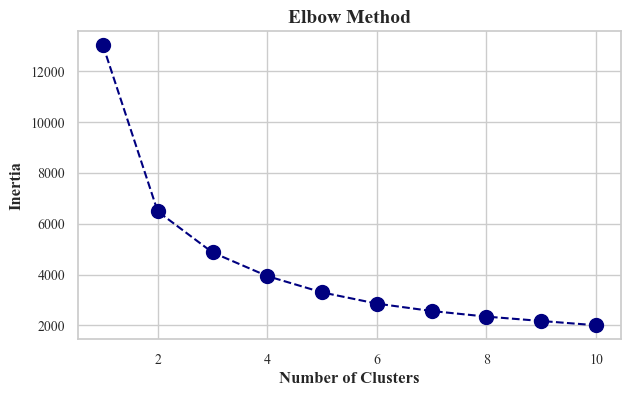

In [95]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters= k, random_state= 42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, color= "navy", linestyle= "dashed", marker= "o", markersize= 10)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## Final KMeans Clustering (k = 4)

Based on the Elbow Method analysis, we selected 4 clusters as the optimal number of customer segments.

In this step:
- We fit the final KMeans model
- Assign cluster labels to each customer
- Prepare for cluster interpretation

In [96]:
kmeans = KMeans(n_clusters= 4, random_state= 42)
clusters = kmeans.fit_predict(rfm_scaled)

rfm["Cluster"] = clusters

## Cluster Profiling

To understand the behavioral characteristics of each cluster, we compute the average Recency, Frequency, and Monetary values.

This allows us to interpret:
- Which cluster represents high-value customers
- Which cluster contains at-risk customers
- Which cluster represents low-engagement customers

In [97]:
cluster_summary = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .sort_values(by= "Monetary", ascending= False)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
1,12.237099,13.711297,8080.217448
3,71.601023,4.064791,1792.806797
0,17.677925,2.178528,557.879288
2,181.597282,1.315627,341.227728


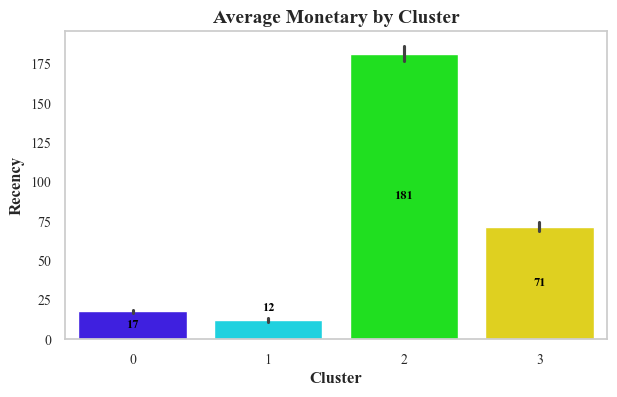

In [98]:
ax = sns.barplot(data= rfm, 
                 x= "Cluster", y= "Recency", 
                 palette= "gist_rainbow_r")

plt.title("Average Monetary by Cluster")

annotate_smart(ax)
plt.show()

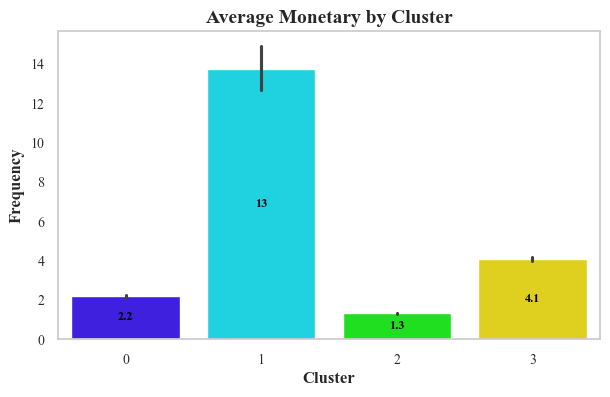

In [99]:
ax = sns.barplot(data= rfm, 
                 x="Cluster", y="Frequency", 
                 palette= "gist_rainbow_r")

plt.title("Average Monetary by Cluster")

annotate_smart(ax)
plt.show()

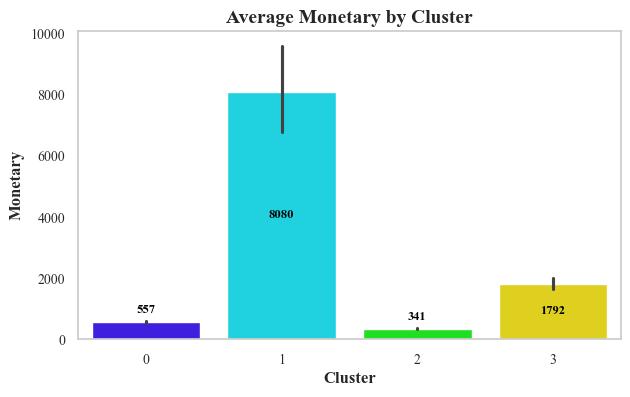

In [100]:
ax = sns.barplot(data= rfm, 
                 x= "Cluster", y= "Monetary", 
                 palette= "gist_rainbow_r")

plt.title("Average Monetary by Cluster")

annotate_smart(ax)
plt.show()

## Comparison Between Rule-Based Segmentation and KMeans Clusters

To evaluate how data-driven clustering aligns with the previously defined RFM rule-based segments, we analyze the cross-distribution of customers across both segmentation approaches.

In [101]:
pd.crosstab(rfm["Segment"], rfm["Cluster"])

Cluster,0,1,2,3
Segment,,,,
At Risk,0,5,37,233
Champions,178,677,0,284
Lost,0,0,1009,56
Loyal Customers,6,33,5,277
Others,348,2,556,313
Potential Loyalists,297,0,12,10


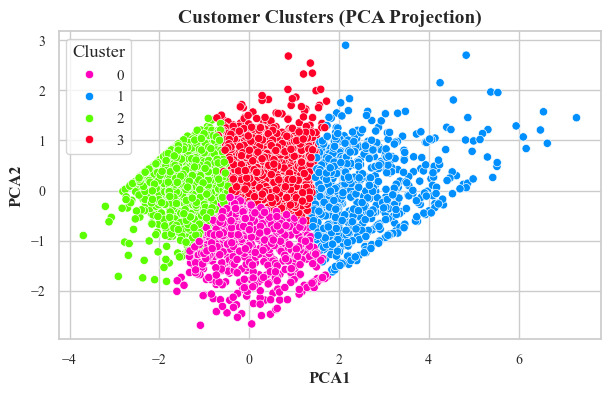

In [102]:
pca = PCA(n_components= 2)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

sns.scatterplot(data= rfm, 
                x= "PCA1", y= "PCA2", 
                hue= "Cluster", 
                marker= "o", 
                palette= "gist_rainbow_r")

plt.title("Customer Clusters (PCA Projection)")
plt.show()

## Business Interpretation of Clusters

In this section, we translate cluster statistics into actionable business insights.

Each cluster will be labeled based on:
- Recency behavior
- Purchase frequency
- Revenue contribution

In [103]:
cluster_map = {
    1: "High Value",
    3: "Mid Value",
    0: "Occasional",
    2: "Lost"
}

rfm["Cluster_Label"] = rfm["Cluster"].map(cluster_map)

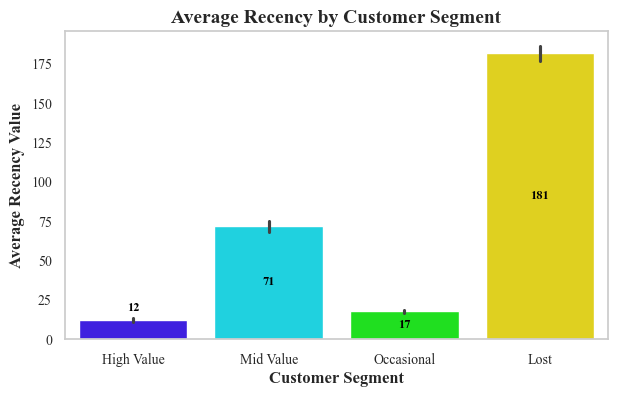

In [104]:
order = ["High Value", "Mid Value", "Occasional", "Lost"]

ax = sns.barplot(data= rfm, 
                 x= "Cluster_Label", y= "Recency", 
                 order= order, 
                 palette= "gist_rainbow_r")

plt.title("Average Recency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Recency Value")

annotate_smart(ax)
plt.show()

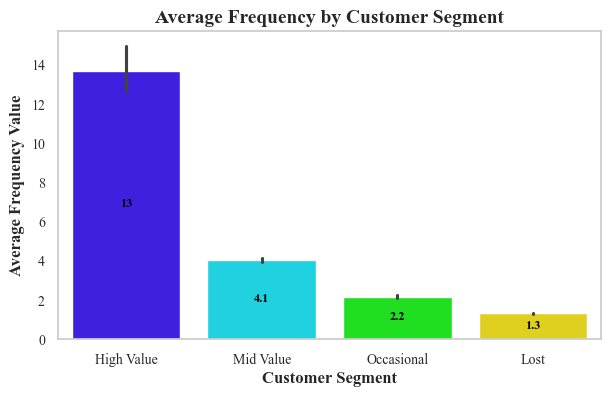

In [105]:
order = ["High Value", "Mid Value", "Occasional", "Lost"]

ax = sns.barplot(data= rfm, 
                 x= "Cluster_Label", y= "Frequency",
                 order= order, 
                 palette= "gist_rainbow_r")

plt.title("Average Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Frequency Value")

annotate_smart(ax)
plt.show()

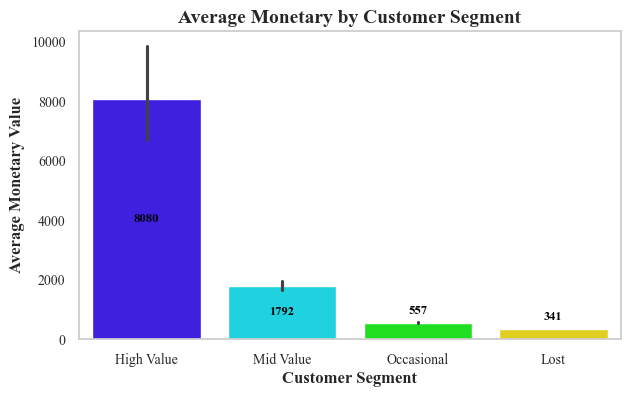

In [106]:
order = ["High Value", "Mid Value", "Occasional", "Lost"]

ax = sns.barplot(data= rfm, 
                 x= "Cluster_Label", y= "Monetary",
                 order= order, 
                 palette= "gist_rainbow_r")

plt.title("Average Monetary by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary Value")

annotate_smart(ax)
plt.show()

## Final Cluster Interpretation

Cluster 1 represents high-value customers with low recency, high purchase frequency, and strong revenue contribution.

Cluster 3 contains mid-value active customers with moderate engagement.

Cluster 0 represents occasional buyers who purchased recently but show low frequency and monetary contribution.

Cluster 2 includes inactive customers with high recency and low engagement, indicating churn risk.

## Business Strategy Recommendations by Cluster

Based on behavioral clustering results, we propose targeted marketing and retention strategies for each customer segment to maximize revenue and reduce churn.

In [107]:
revenue_share = (
    rfm.groupby("Cluster_Label")["Monetary"]
    .sum()
    .sort_values(ascending= False)
)

revenue_share

Cluster_Label
High Value    5793515.910
Mid Value     2102962.373
Lost           552447.691
Occasional     462481.930
Name: Monetary, dtype: float64

In [108]:
cluster_distribution = rfm["Cluster_Label"].value_counts(normalize= True) * 100
cluster_distribution

Cluster_Label
Lost          37.321346
Mid Value     27.040111
Occasional    19.110189
High Value    16.528354
Name: proportion, dtype: float64

# Final Conclusion

In this project, we developed a complete customer segmentation pipeline from raw transactional data to business-level strategic insights.

Key Achievements:

- Constructed RFM features to capture customer behavior
- Built rule-based customer segments for initial profiling
- Applied KMeans clustering to uncover data-driven customer groups
- Validated clustering structure using the Elbow Method
- Visualized cluster separation using PCA
- Translated analytical results into actionable marketing strategies

The clustering results revealed clear behavioral distinctions among customers, including high-value customers, mid-value customers, occasional buyers,
and inactive customers.

This segmentation framework enables businesses to:

- Improve retention of high-value customers
- Increase engagement of mid-value customers
- Reactivate churned customers
- Optimize marketing resource allocation

Overall, this project demonstrates how analytical modeling can be transformed into practical decision-making support for customer strategy.